In [8]:
import pandas as pd

train_df = pd.read_csv('../../data/titanic_train.csv')
test_df = pd.read_csv('../../data/titanic_test.csv')

### 6.a Checking Total Number & Percentage of Missing Values in Training Dataset

In [9]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df_missing = ((train_df.isnull().sum()[train_df.isnull().sum() > 0])
                .to_frame().rename(columns={0: "Number of Missing values"}))
df_missing["% of Missing Values"] = round((100 * train_df.isnull().sum()[train_df.isnull().sum() > 0] / len(train_df)),
                                          2)
df_missing

,Number of Missing values,% of Missing Values
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [11]:
train_df.notna().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

### 6.b Checking Total Number & Percentage of Missing Values in Test Dataset

In [12]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [14]:
df_missing = (test_df.isnull().sum()[test_df.isnull().sum() > 0]).to_frame().rename(columns={0: "Number of Missing values"})
df_missing["% of Missing Values"] = round((100 * test_df.isnull().sum()[test_df.isnull().sum() > 0] / len(test_df)), 2)

df_missing

,Number of Missing values,% of Missing Values
Age,86,20.57
Fare,1,0.24
Cabin,327,78.23


### 7. Visualizing (missing and existing) numbers

Text(0.5, 1.0, 'Training Dataset vs. Test Dataset (nr of values)')

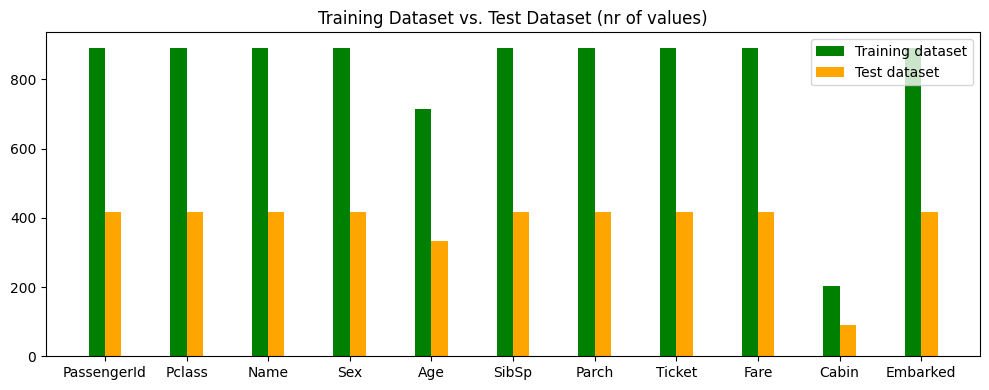

In [15]:
from matplotlib import pyplot as plt
import numpy as np

chart_x = train_df.drop('Survived', axis=1).notna().sum().index
chart_y1 = train_df.drop('Survived', axis=1).notna().sum()
chart_y2 = test_df.notna().sum()

width = 0.2
x = np.arange(len(chart_x))

plt.figure(figsize=(10, 4), tight_layout=True)
plt.bar(x - width / 2, chart_y1, width, color="green")
plt.bar(x + width / 2, chart_y2, width, color="orange")
plt.xticks(x, chart_x)
plt.legend(["Training dataset", "Test dataset"])
plt.title("Training Dataset vs. Test Dataset (nr of values)")